# 07 — CNNs in Depth and Modern Image Classification

Topics:
- Batch Normalization
- Dropout
- Data augmentation
- Learning-rate scheduling
- Early stopping
- Confusion matrices
- Precision, Recall, F1
- Transfer learning
- Feature extraction vs fine-tuning
- ResNet and pretrained models
- Practical CNN training workflow

# 1. Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.9.1
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


# 2. CNN Review

A basic CNN is:

```text
Image
  ↓
Conv2d
  ↓
ReLU
  ↓
Pooling
  ↓
Conv2d
  ↓
ReLU
  ↓
Pooling
  ↓
Flatten
  ↓
Linear
  ↓
Logits
```

Practical CNNs often add normalization, regularization, residual connections, and better training strategies.

# 3. Batch Normalization

For CNNs, PyTorch provides `nn.BatchNorm2d(num_features)`. A common block is `Conv2d → BatchNorm2d → ReLU`.

In [2]:
bn = nn.BatchNorm2d(16)
x = torch.randn(8, 16, 32, 32)
y = bn(x)

print("Input:", x.shape)
print("Output:", y.shape)

Input: torch.Size([8, 16, 32, 32])
Output: torch.Size([8, 16, 32, 32])


## Why BatchNorm?

BatchNorm normalizes activations using batch statistics during training and running statistics during evaluation. It can make optimization more stable.

This is another reason `model.train()` and `model.eval()` matter.

# 4. BatchNorm CNN Block

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)

block = ConvBlock(3, 32)
print(block(torch.randn(8, 3, 64, 64)).shape)

torch.Size([8, 32, 64, 64])


# 5. Dropout

Dropout randomly zeros activations during training.

```python
nn.Dropout(p=0.3)
```

With `p=0.3`, roughly 30% of activations are dropped during a training forward pass.

During evaluation, Dropout is disabled.

In [4]:
dropout = nn.Dropout(p=0.5)
x = torch.ones(20)

dropout.train()
train_output = dropout(x)

dropout.eval()
eval_output = dropout(x)

print("Training:", train_output)
print("Evaluation:", eval_output)

Training: tensor([0., 2., 0., 2., 0., 0., 0., 0., 2., 2., 2., 2., 0., 2., 0., 0., 2., 0.,
        2., 0.])
Evaluation: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1.])


# 6. Regularized CNN

A practical CNN block can combine:

```text
Conv
 ↓
BatchNorm
 ↓
ReLU
 ↓
Pooling
```

and use Dropout near the classifier.

In [5]:
class RegularizedCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

print(RegularizedCNN())

RegularizedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, b

# 7. Data Augmentation

Augmentation creates varied training examples:

```text
Original
 ├── Random crop
 ├── Horizontal flip
 ├── Small rotation
 └── Color variation
```

The transformation must preserve the class meaning.

For example, a horizontal flip may be valid for some objects but inappropriate for text or some traffic signs.

# 8. Training vs Evaluation Transforms

Typical pattern:

```text
Training:
Resize
Random crop
Random flip
ToTensor
Normalize

Validation/Test:
Resize
ToTensor
Normalize
```

Random training augmentation should normally not be applied to the validation/test set.

# 9. Example `torchvision` Transforms

If torchvision is installed:

```python
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
```

Choose normalization and augmentation according to the dataset and model.

# 10. Learning Rate

A simplified gradient-descent update is:

```text
new_parameter =
old_parameter - learning_rate × gradient
```

Too large:

```text
unstable / overshooting
```

Too small:

```text
slow learning
```

A scheduler changes the learning rate during training.

# 11. StepLR

In [6]:
model_demo = nn.Linear(10, 3)
optimizer_demo = torch.optim.Adam(model_demo.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer_demo,
    step_size=3,
    gamma=0.1
)

for epoch in range(10):
    lr = optimizer_demo.param_groups[0]["lr"]
    print(f"Epoch {epoch+1}: lr={lr:.6f}")
    scheduler.step()

Epoch 1: lr=0.001000
Epoch 2: lr=0.001000
Epoch 3: lr=0.001000
Epoch 4: lr=0.000100
Epoch 5: lr=0.000100
Epoch 6: lr=0.000100
Epoch 7: lr=0.000010
Epoch 8: lr=0.000010
Epoch 9: lr=0.000010
Epoch 10: lr=0.000001


c:\Users\dhana\miniconda3\envs\DL_Torch\Lib\site-packages\torch\optim\lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


# 12. ReduceLROnPlateau

`ReduceLROnPlateau` can react to a metric that stops improving.

Conceptually:

```text
Validation loss improves
        ↓
keep LR

Validation loss stops improving
        ↓
reduce LR
```

In [7]:
model_demo = nn.Linear(10, 3)
optimizer_demo = torch.optim.Adam(model_demo.parameters(), lr=0.001)

plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_demo,
    mode="min",
    factor=0.5,
    patience=2
)

print(plateau_scheduler)

# 13. Early Stopping

Early stopping monitors validation performance.

Example logic:

```python
if val_loss < best_val_loss:
    best_val_loss = val_loss
    patience_counter = 0
    save_model()
else:
    patience_counter += 1

if patience_counter >= patience:
    stop_training()
```

The important idea is to stop when validation performance has not improved for a chosen patience period.

# 14. Classification Metrics

Accuracy is:

```text
correct / total
```

But accuracy alone may hide poor performance on minority classes.

Useful metrics include:

- Confusion matrix
- Precision
- Recall
- F1 score

# 15. Confusion Matrix

For three classes:

```text
                 Predicted
              0     1     2
Actual 0     [ ]   [ ]   [ ]
       1     [ ]   [ ]   [ ]
       2     [ ]   [ ]   [ ]
```

Diagonal entries are correct predictions. Off-diagonal entries are errors.

In [8]:
def confusion_matrix_torch(y_true, y_pred, num_classes):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)

    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1

    return cm

true = torch.tensor([0, 0, 1, 1, 2, 2, 2])
pred = torch.tensor([0, 1, 1, 2, 2, 2, 0])

cm = confusion_matrix_torch(true, pred, 3)
print(cm)

tensor([[1, 1, 0],
        [0, 1, 1],
        [1, 0, 2]])


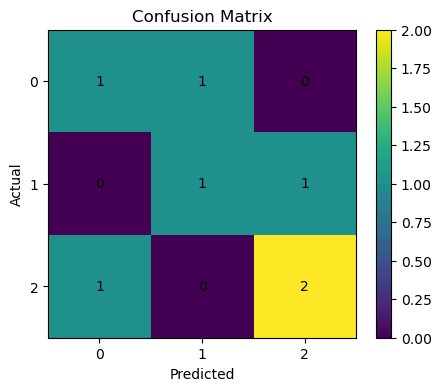

In [9]:
plt.figure(figsize=(5, 4))
plt.imshow(cm.numpy())
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j].item(), ha="center", va="center")

plt.xticks(range(3))
plt.yticks(range(3))
plt.show()

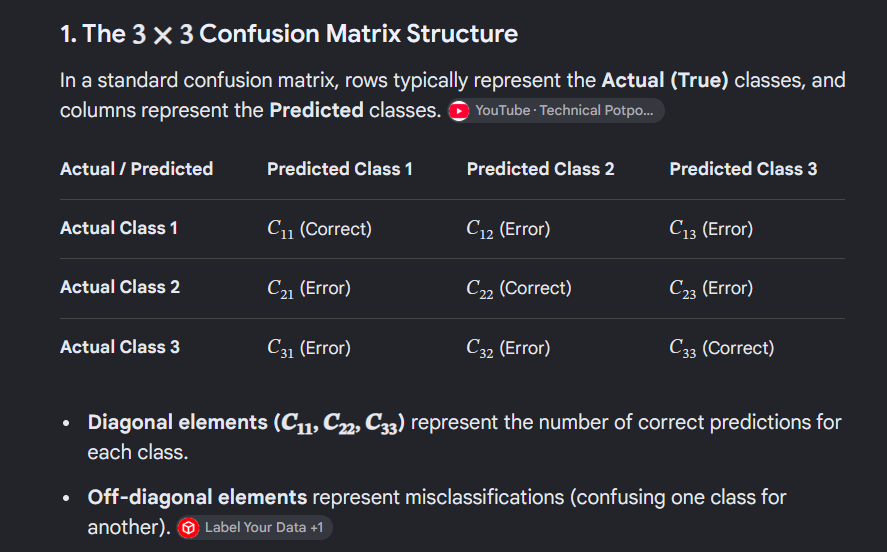

# 16. Precision

For one class:

```text
Precision =
TP / (TP + FP)
```

It answers:

> Of the samples predicted as this class, how many were actually this class?

# 17. Recall

For one class:

```text
Recall =
TP / (TP + FN)
```

It answers:

> Of all actual samples belonging to this class, how many did the model find?

# 18. F1 Score

```text
F1 = 2 × Precision × Recall
     ------------------------
       Precision + Recall
```

F1 combines precision and recall into one measure.

In [10]:
def classification_metrics(cm):
    precision, recall, f1 = [], [], []

    for c in range(cm.shape[0]):
        tp = cm[c, c].float()
        fp = cm[:, c].sum().float() - tp
        fn = cm[c, :].sum().float() - tp

        p = tp / (tp + fp + 1e-8)
        r = tp / (tp + fn + 1e-8)
        f = 2 * p * r / (p + r + 1e-8)

        precision.append(p.item())
        recall.append(r.item())
        f1.append(f.item())

    return precision, recall, f1

precision, recall, f1 = classification_metrics(cm)

for c in range(3):
    print(f"Class {c}: Precision={precision[c]:.3f}, "
          f"Recall={recall[c]:.3f}, F1={f1[c]:.3f}")

Class 0: Precision=0.500, Recall=0.500, F1=0.500
Class 1: Precision=0.500, Recall=0.500, F1=0.500
Class 2: Precision=0.667, Recall=0.667, F1=0.667


# 19. Macro vs Weighted Metrics

**Macro average:** calculate each class metric and average them equally.

**Weighted average:** weight each class according to its number of samples.

Macro is useful when every class should receive equal importance. Weighted metrics reflect class frequency.

# 20. Transfer Learning

Instead of training a large CNN from scratch:

```text
Large dataset
     ↓
Pretrained CNN
     ↓
General visual features
     ↓
Your dataset
     ↓
New classifier
```

This is **transfer learning**.

# 21. Feature Extraction vs Fine-Tuning

### Feature extraction

```text
Pretrained backbone → frozen
                         ↓
                    new classifier
                         ↓
                       train
```

### Fine-tuning

```text
Pretrained backbone → partially/fully trainable
                         ↓
                    new classifier
```

Fine-tuning usually uses a smaller learning rate for pretrained layers.

# 22. Why Transfer Learning Works

Early visual layers often learn broadly useful patterns:

```text
edges
textures
corners
simple shapes
```

These can transfer to a new image task, especially when the new dataset is not huge.

# 23. ResNet and Residual Connections

A residual block learns approximately:

```text
output = F(x) + x
```

instead of requiring every layer to completely transform `x`.

Conceptually:

```text
        ┌──────────────┐
        │              ↓
x ─────→ Conv → Conv → Add → output
│                     ↑
└─────────────────────┘
```

This shortcut is called a residual connection.

# 24. Load a Pretrained ResNet

With a recent torchvision version:

```python
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
```

The exact available weights depend on your installed torchvision version.

In [11]:
try:
    from torchvision.models import resnet18, ResNet18_Weights

    weights = ResNet18_Weights.DEFAULT
    pretrained_resnet = resnet18(weights=weights)

    print("Loaded pretrained ResNet-18")
    print("Original classifier:", pretrained_resnet.fc)

except Exception as e:
    print("Could not load pretrained ResNet in this environment.")
    print("Reason:", e)

2.0%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\dhana/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Loaded pretrained ResNet-18
Original classifier: Linear(in_features=512, out_features=1000, bias=True)


# 25. Replace the ResNet Classifier

If your dataset has 5 classes:

```python
model.fc = nn.Linear(
    model.fc.in_features,
    5
)
```

The backbone extracts features and the new head produces 5 logits.

In [12]:
try:
    num_classes = 5

    transfer_model = resnet18(weights=ResNet18_Weights.DEFAULT)
    transfer_model.fc = nn.Linear(
        transfer_model.fc.in_features,
        num_classes
    )

    print(transfer_model.fc)

except Exception as e:
    print("Run the previous ResNet setup successfully first.")
    print(e)

Linear(in_features=512, out_features=5, bias=True)


# 26. Freeze the Backbone

For feature extraction:

```python
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True
```

Then optimize only parameters with `requires_grad=True`.

In [13]:
try:
    for param in transfer_model.parameters():
        param.requires_grad = False

    for param in transfer_model.fc.parameters():
        param.requires_grad = True

    trainable = sum(
        p.numel() for p in transfer_model.parameters()
        if p.requires_grad
    )
    total = sum(p.numel() for p in transfer_model.parameters())

    print("Trainable parameters:", trainable)
    print("Total parameters:", total)

except NameError:
    print("Run the ResNet cells first.")

Trainable parameters: 2565
Total parameters: 11179077


# 27. Optimizer for Feature Extraction

Use only trainable parameters:

```python
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)
```

# 28. Fine-Tuning

After training the new classifier, you can unfreeze later backbone layers.

A common pattern is:

```text
Early layers → frozen
Later layers → trainable
Classifier → trainable
```

Use a smaller learning rate, for example:

```text
1e-5
```

The exact value depends on the problem.

# 29. Overfitting

A common pattern is:

```text
Training loss ↓↓↓
Validation loss ↓ then ↑↑
```

and:

```text
Training accuracy ↑↑
Validation accuracy stops improving
```

Possible responses:

- More data
- Augmentation
- Weight decay
- Dropout
- Smaller model
- Early stopping
- Transfer learning

# 30. Underfitting

If both training and validation performance remain poor, possible causes include:

- Model too small
- Insufficient training
- Learning-rate problem
- Poor preprocessing
- Excessive regularization

Possible responses include increasing model capacity, improving training, or reducing excessive regularization.

# 31. Weight Decay

You studied AdamW earlier. It is commonly useful in CNN training:

```python
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
```

Weight decay is a regularization mechanism that discourages unnecessarily large parameter values.

# 32. Save the Best Model

Instead of saving only the final epoch:

```python
if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(model.state_dict(), "best_model.pth")
```

Then load the best checkpoint before final testing.

In [14]:
best_val_acc = -1.0

# Inside a real training loop:
#
# if val_acc > best_val_acc:
#     best_val_acc = val_acc
#     torch.save(model.state_dict(), "best_model.pth")

print("Best-checkpoint pattern demonstrated.")

Best-checkpoint pattern demonstrated.


# 33. Practical Image Classification Pipeline

```text
Collect images
      ↓
Clean labels
      ↓
Train / validation / test split
      ↓
Transforms
      ↓
Dataset
      ↓
DataLoader
      ↓
CNN / pretrained model
      ↓
Train
      ↓
Validate
      ↓
Inspect errors
      ↓
Fine-tune / improve
      ↓
Final test
      ↓
Save model
      ↓
Deploy
```

# 34. Error Analysis

Do not only inspect accuracy.

Look at wrong predictions:

```text
Predicted: Class A
Actual:    Class B
```

Ask:

- Is the label correct?
- Is the image ambiguous?
- Are classes visually similar?
- Is one class underrepresented?
- Is preprocessing wrong?
- Does the model repeatedly confuse these classes?

Error analysis often reveals problems hidden by aggregate metrics.

# 35. Edge Deployment

For devices such as a Raspberry Pi, model size and inference speed matter.

Possible approaches:

- MobileNet-style models
- Smaller input resolution
- Quantization
- ONNX
- TensorRT where supported
- Pruning

The goal is not always the largest model; it is an appropriate accuracy/speed trade-off.